DataFrame created: 253,680 rows × 22 columns

First 20 rows:
Missing values per column:
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64
Rows with missing values: 0

Total missing values: 0

Missing Values Summary:
                      Missing_Count  Missing_Percentage
HighBP                            0                 0.0
HighChol                          0                 0.0
CholCheck                         0                 0.0
BMI                      

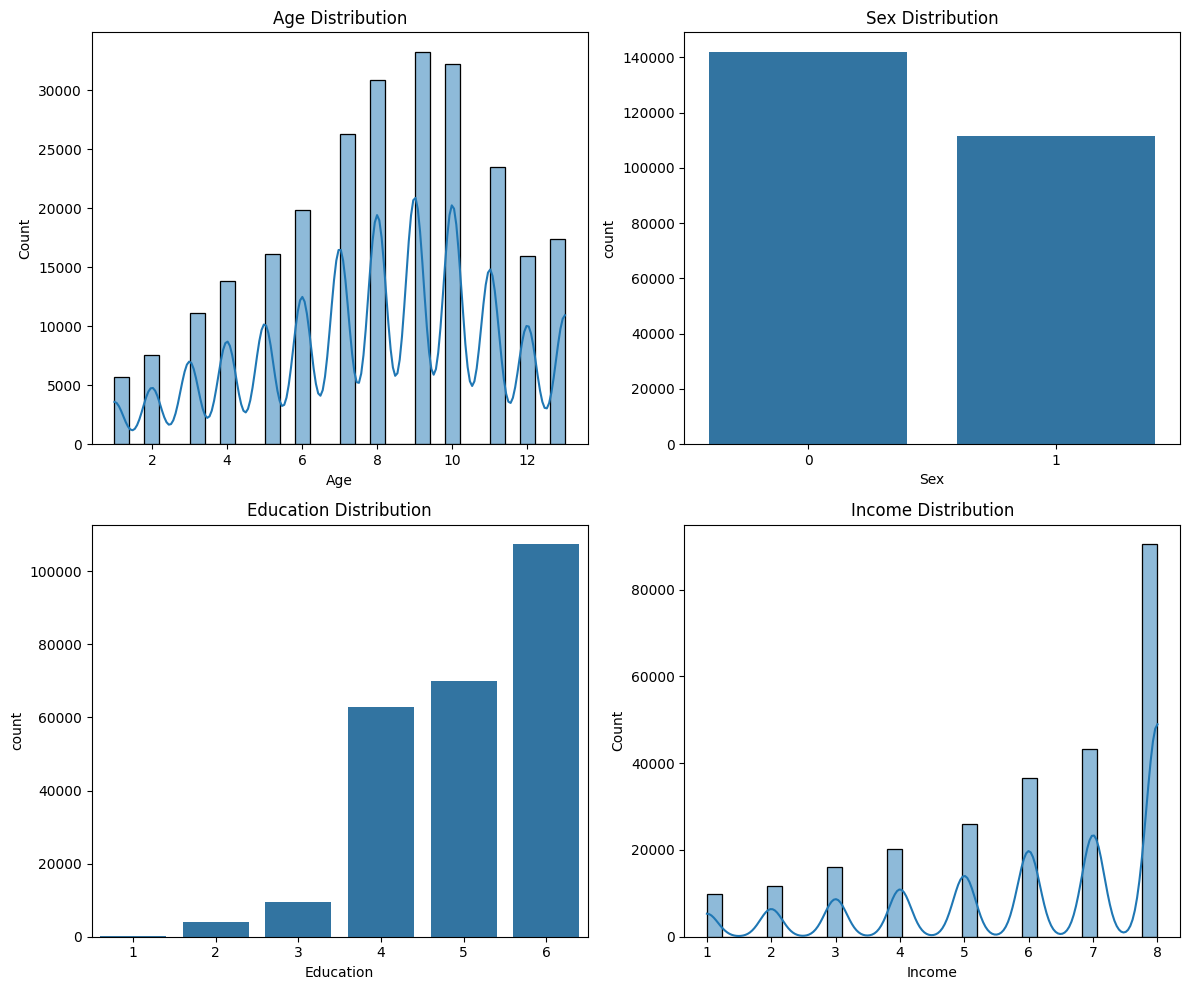

In [54]:
#Import Libraries for Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Import Data Set

import ucimlrepo

from ucimlrepo import fetch_ucirepo, list_available_datasets

fetch_ucirepo(name='CDC Diabetes Health Indicators')


#Exploratory Data Analysis

dataset = fetch_ucirepo(name='CDC Diabetes Health Indicators')
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

print(f"DataFrame created: {df.shape[0]:,} rows × {df.shape[1]} columns")


print("\nFirst 20 rows:")
df.head()

#Check for Missing Values

print("Missing values per column:")
print(df.isnull().sum())

rows_with_missing = df.isnull().any(axis=1).sum()
print(f"Rows with missing values: {rows_with_missing:,}")

total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing:,}")

missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
print("\nMissing Values Summary:")
print(missing_summary)

#Trimmed Columns

df_trimmed = df[['Age', 'Sex', 'Education', 'Income']].copy()
print(f"✓ df_trimmed: {df_trimmed.shape}")

#Clean DF

df_clean = df_trimmed.dropna()
print(f"✓ df_clean: {df_clean.shape}")

df_plot = df_clean
print(f"✓ df_plot: {df_plot.shape}")


#Visualizations

df_plot = df_clean


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df_plot['Age'], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title('Age Distribution')

sns.countplot(x='Sex', data=df_plot, ax=axes[0,1])
axes[0,1].set_title('Sex Distribution')

sns.countplot(x='Education', data=df_plot, ax=axes[1,0])
axes[1,0].set_title('Education Distribution')

sns.histplot(df_plot['Income'], bins=30, kde=True, ax=axes[1,1])
axes[1,1].set_title('Income Distribution')

plt.tight_layout()
plt.show()